EEG Motor Imagery Project - Exploring the Data

In this notebook, I intend to explore the BCI Competition IV Dataset 2a. My goal is to understand the structure of EEG data so that I can use it for machine learning later on in the project.

I want to look at the EEG channels, the sampling frewuency, the recording length, the raw EEG signals, and the event markers for motor imagery.

In [55]:
# mne is the main Python library for the EEG data and I want to use matplotlib to make the plots
import mne
import matplotlib.pyplot as plt

file_path = "/Users/vaneeza/EEG_BCI_Project/data/BCICIV_2a_gdf/A01T.gdf"
raw = mne.io.read_raw_gdf(file_path, preload=True)
print (raw)

print("Number of channels:", raw.info["nchan"])
# The file contains 25 recorded channels (22 EEG, 3 EOG)
print("Channel names:", raw.info["ch_names"])
print("Sampling frequency:", raw.info["sfreq"], "Hz")
# Sampling Frequency: Number of measurements recorded each second

Extracting GDF parameters from /Users/vaneeza/EEG_BCI_Project/data/BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>
Number of channels: 25
Channel names: ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
Sampling frequency: 250.0 Hz


Object 'raw' contains one participant's full continuous EEG recording. This includes recorded signals, information about channels, the sampling frequency, as well as any event annotations.

In [56]:
# Recording Duration
number_of_samples = raw.n_times
sampling_frequency = raw.info["sfreq"]
recording_duration = number_of_samples / sampling_frequency
duration_seconds = number_of_samples / sampling_frequency
duration_minutes = duration_seconds / 60

print ("Number of Samples:", number_of_samples)
print("Recording Duration in seconds:", duration_seconds)
print("Recording Duration in minutes:", duration_minutes)

Number of Samples: 672528
Recording Duration in seconds: 2690.112
Recording Duration in minutes: 44.8352


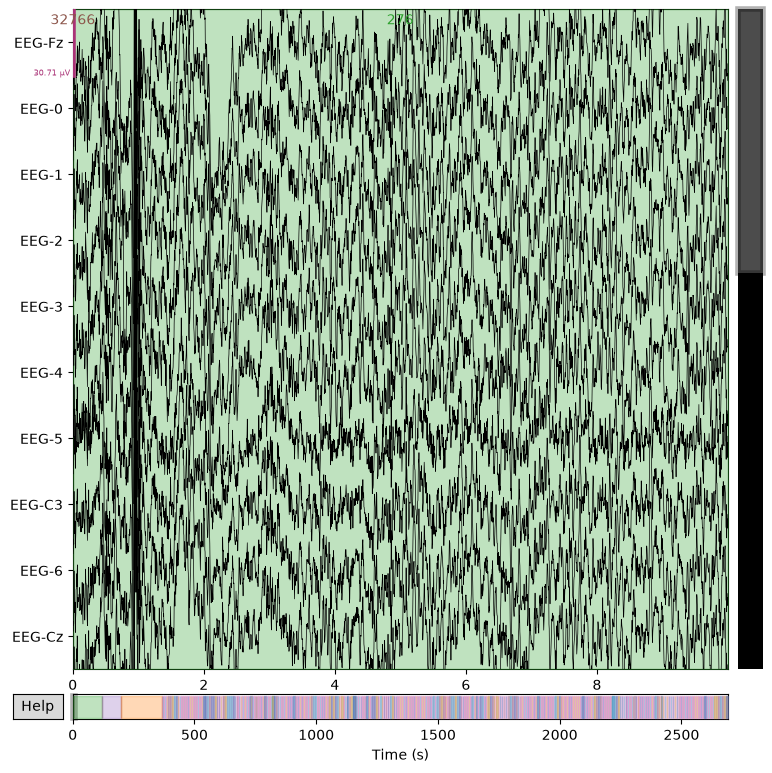

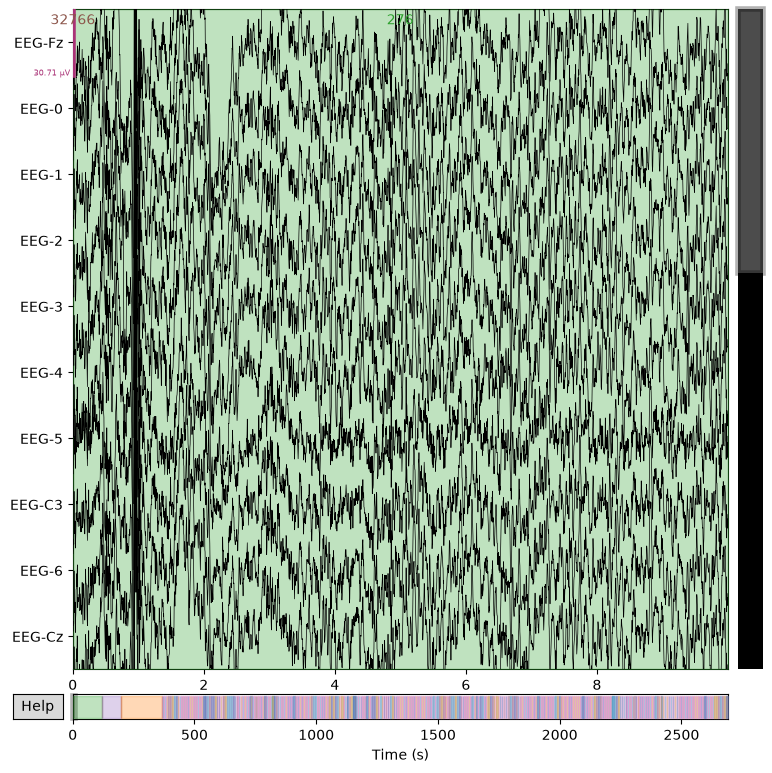

In [57]:
raw.plot (duration = 10, n_channels = 10, scalings = "auto", title = "Plot of raw EEG" )
# Each line is one recorded channel of EEG data.
# Signals look noisy as EEG contains brain activity and many sources of electrical variation.

In [58]:
print(raw.annotations)
print(raw.annotations.description)
# When did different motor imagery trials occur?

<Annotations | 603 segments: 1023 (15), 1072 (1), 276 (1), 277 (1), 32766 ...>
['32766' '276' '32766' '277' '32766' '1072' '32766' '768' '772' '768'
 '771' '768' '770' '768' '769' '768' '769' '768' '770' '768' '771' '768'
 '772' '768' '770' '768' '771' '768' '769' '768' '769' '768' '769' '768'
 '772' '768' '770' '768' '770' '768' '769' '768' '769' '768' '771' '768'
 '769' '768' '770' '768' '1023' '772' '768' '772' '768' '771' '768' '769'
 '768' '772' '768' '772' '768' '770' '768' '772' '768' '772' '768' '770'
 '768' '769' '768' '770' '768' '771' '768' '771' '768' '771' '768' '772'
 '768' '771' '768' '769' '768' '772' '768' '770' '768' '771' '768' '770'
 '768' '771' '768' '772' '768' '1023' '770' '768' '771' '768' '769'
 '32766' '768' '769' '768' '769' '768' '772' '768' '770' '768' '1023'
 '769' '768' '771' '768' '769' '768' '771' '768' '1023' '770' '768' '772'
 '768' '769' '768' '771' '768' '771' '768' '769' '768' '771' '768' '770'
 '768' '772' '768' '772' '768' '772' '768' '1023' '771

In [59]:
events, event_id = mne.events_from_annotations (
    raw,
    event_id = "auto"
)
print(event_id)
# Display only the first 10 events in the recording
print(events[:10])

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
[[    0     0     5]
 [    0     0     3]
 [29683     0     5]
 [29683     0     4]
 [49955     0     5]
 [49955     0     2]
 [91518     0     5]
 [91868     0     6]
 [92368     0    10]
 [93871     0     6]]


Reference: main motor imagery codes
770 = right hand
769 = left hand
771 = feet
772 = tongue

In [60]:
# How many trials of each type were recorded?
left_hand_code = event_id["769"]
right_hand_code = event_id["770"]
# Select all rows (:) but only in column 3 (2) and then compare it to the code I need
left_hand_count = sum(events[:, 2] == left_hand_code)
right_hand_count = sum(events[:, 2] == right_hand_code)

print("left hand trials:", left_hand_count)
print("right hand trials:", right_hand_count)

left hand trials: 72
right hand trials: 72


The EEG recording contains continuous signals from multiple scalp electrodes and event markers that identify when the participant was asked to imagine different movements. This raw recording needs to be processed before it can be used for machine learning as it has continuous data, different types of channels, noise, and a record of every experimental event. Next, I need to isolate the motor imargey trials and preprocess the EEG signals for those events.